# Nama: Tenno Cahyo Berliantoko

# NIM: 25/568393/PA/23995

# PCD Assignment 02 - Image Enhancement Based on Filtering

## Image Enhancement on One Input Image

Pada tugas ini digunakan 1 gambar sebagai objek pengolahan. Implementasi mencakup beberapa teknik image enhancement yang dibahas pada materi, yaitu spatial filtering dan frequency-domain filtering.

### Teknik yang digunakan
- Smoothing Linear Filter (Mean Filter)
- Gaussian Filter
- Median Filter
- Sharpening Spatial Filter (Laplacian)
- Low-Pass Filtering
- High-Pass Filtering
- Gaussian Low-Pass Filter
- Ideal Low-Pass Filter
- Ringing and Blurring
- Butterworth Low-Pass Filter
- Ideal High-Pass Filter
- Butterworth High-Pass Filter
- Gaussian High-Pass Filter
- Laplacian High-Pass Filter

Tujuan percobaan adalah membandingkan perubahan citra asli setelah setiap filter diterapkan dan mengamati pengaruh smoothing, blurring, edge enhancement, serta filtering pada domain frekuensi.

In [16]:
# Import libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from google.colab import drive

In [17]:
# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
# Folder input dan output
INPUT_FOLDER = "/content/drive/MyDrive/PCD_Assignment02/images"
OUTPUT_FOLDER = "/content/drive/MyDrive/PCD_Assignment02/results"

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# Pilih SATU gambar untuk tugas ini.
# Ganti nama file sesuai gambar yang kamu pilih.
IMAGE_NAME = "Potret.jpg"
IMAGE_PATH = os.path.join(INPUT_FOLDER, IMAGE_NAME)

print("Image path:", IMAGE_PATH)
print("Output folder:", OUTPUT_FOLDER)

Image path: /content/drive/MyDrive/PCD_Assignment02/images/Potret.jpg
Output folder: /content/drive/MyDrive/PCD_Assignment02/results


Image shape: (540, 429, 3)


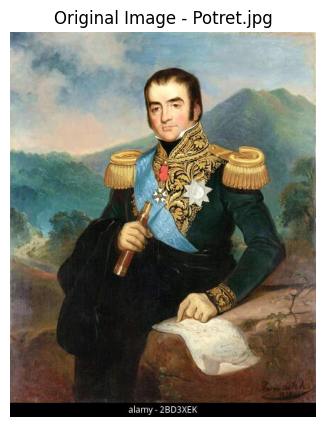

In [19]:
# Membaca satu gambar
image_bgr = cv2.imread(IMAGE_PATH)

if image_bgr is None:
    raise FileNotFoundError(
        f"Gambar tidak ditemukan: {IMAGE_PATH}. "
        f"Pastikan file sudah dimasukkan ke folder {INPUT_FOLDER}."
    )

image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

print("Image shape:", image.shape)

plt.figure(figsize=(7, 5))
plt.imshow(image)
plt.title(f"Original Image - {IMAGE_NAME}")
plt.axis("off")
plt.show()


## Image Conditions for the Input Image

Dari foto 1 yang diinputkan, dibuat beberapa kondisi citra untuk melihat perbedaan image enhancement: Blurred Image, Dark Image, Bright Image, Low-Contrast Image, dan Salt & Pepper Noise.


In [20]:
# Membuat beberapa kondisi dari foto 1 yang diinputkan

# 1. Blurred Image
blurred_image = cv2.GaussianBlur(image, (21, 21), 8)

# 2. Dark Image
dark_image = np.clip(image.astype(np.float32) * 0.35, 0, 255).astype(np.uint8)

# 3. Bright Image
bright_image = np.clip(image.astype(np.float32) * 1.50, 0, 255).astype(np.uint8)

# 4. Low-Contrast Image
mean_intensity = np.mean(image, axis=(0, 1), keepdims=True)
low_contrast_image = mean_intensity + 0.35 * (image.astype(np.float32) - mean_intensity)
low_contrast_image = np.clip(low_contrast_image, 0, 255).astype(np.uint8)

# 5. Salt and Pepper Noise
salt_pepper_image = image.copy()
rng = np.random.default_rng(42)
amount = 0.04
num_pixels = int(amount * image.shape[0] * image.shape[1])
ys = rng.integers(0, image.shape[0], num_pixels)
xs = rng.integers(0, image.shape[1], num_pixels)
half = num_pixels // 2
salt_pepper_image[ys[:half], xs[:half]] = 255
salt_pepper_image[ys[half:], xs[half:]] = 0


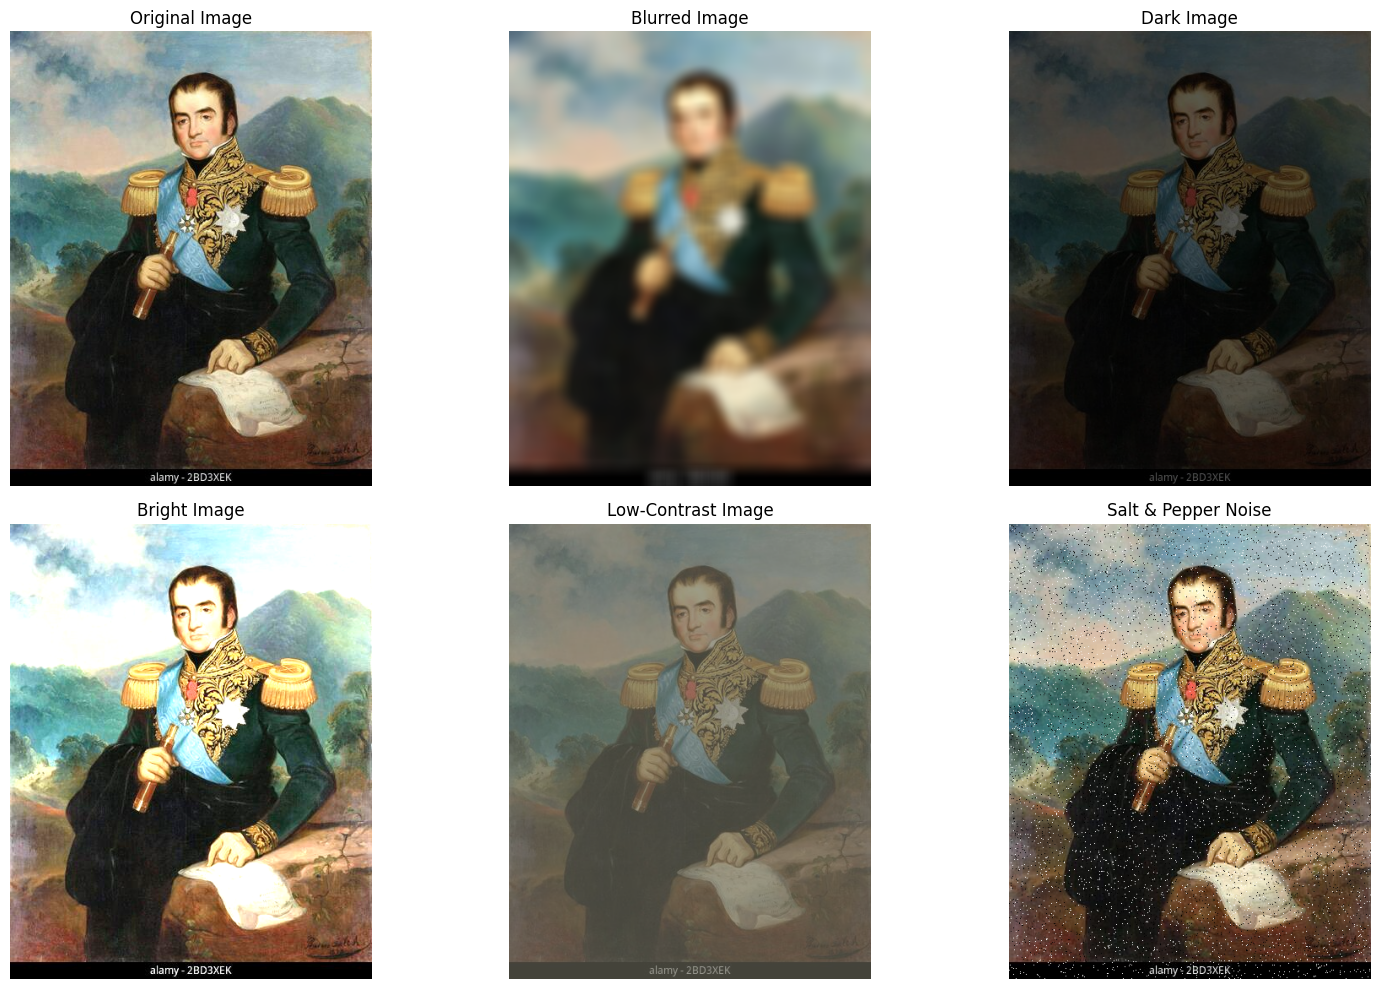

In [21]:
# Menampilkan foto 1 dan semua kondisi turunannya
condition_images = [
    image,
    blurred_image,
    dark_image,
    bright_image,
    low_contrast_image,
    salt_pepper_image
]

condition_titles = [
    "Original Image",
    "Blurred Image",
    "Dark Image",
    "Bright Image",
    "Low-Contrast Image",
    "Salt & Pepper Noise"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, img, title in zip(axes.ravel(), condition_images, condition_titles):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()


## 1. Spatial Domain Filtering

Spatial filtering memodifikasi nilai piksel berdasarkan lingkungan lokalnya. Pada bagian ini digunakan smoothing linear, Gaussian, median, dan Laplacian sharpening.

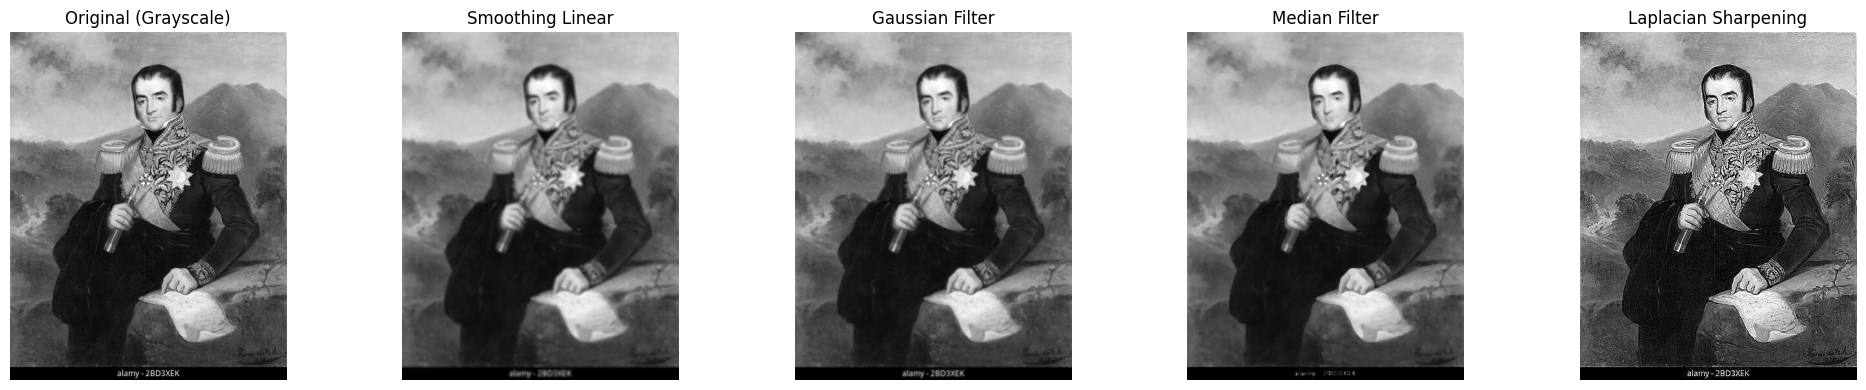

In [22]:
# Spatial filters
def smoothing_linear_filter(img, kernel_size=5):
    return cv2.blur(img, (kernel_size, kernel_size))

def gaussian_filter(img, kernel_size=5, sigma=1.0):
    return cv2.GaussianBlur(img, (kernel_size, kernel_size), sigmaX=sigma)

def median_filter(img, kernel_size=5):
    return cv2.medianBlur(img, kernel_size)

def laplacian_sharpen(img):
    kernel = np.array([[0, 1, 0],
                       [1, -4, 1],
                       [0, 1, 0]], dtype=np.float32)
    lap = cv2.filter2D(img, cv2.CV_32F, kernel)
    sharpened = img.astype(np.float32) - lap
    sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)
    lap_display = cv2.normalize(np.abs(lap), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    return sharpened, lap_display

linear_result = smoothing_linear_filter(gray, 5)
gaussian_result = gaussian_filter(gray, 5, 1.0)
median_result = median_filter(gray, 5)
laplacian_result, laplacian_response = laplacian_sharpen(gray)

results = [gray, linear_result, gaussian_result, median_result, laplacian_result]
titles = [
    "Original (Grayscale)",
    "Smoothing Linear",
    "Gaussian Filter",
    "Median Filter",
    "Laplacian Sharpening"
]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, result, title in zip(axes, results, titles):
    ax.imshow(result, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

### Analisis Spatial Filtering

Smoothing linear mengurangi variasi lokal melalui rata-rata piksel sehingga citra menjadi lebih halus. Gaussian filter memberikan pembobotan yang lebih besar pada piksel di sekitar pusat kernel sehingga menghasilkan smoothing yang lebih gradual. Median filter mengganti nilai piksel dengan median tetangganya dan berguna untuk mengurangi noise impulsif. Laplacian sharpening menonjolkan perubahan intensitas yang cepat, sehingga tepi dan detail citra menjadi lebih terlihat.

## 2. Frequency Domain Filtering

Pada frequency domain, citra ditransformasikan menggunakan Discrete Fourier Transform (DFT). Filter kemudian diterapkan pada spektrum frekuensi, lalu hasilnya dikembalikan ke spatial domain dengan inverse Fourier transform.

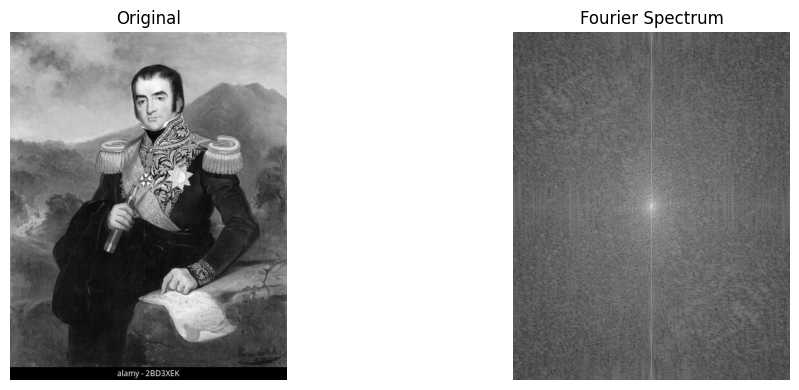

In [23]:
# Fungsi dasar frequency-domain filtering
def distance_matrix(shape):
    rows, cols = shape
    u = np.arange(rows) - rows // 2
    v = np.arange(cols) - cols // 2
    V, U = np.meshgrid(v, u)
    return np.sqrt(U**2 + V**2)

def fft_spectrum(img):
    F = np.fft.fftshift(np.fft.fft2(img.astype(np.float32)))
    spectrum = np.log1p(np.abs(F))
    spectrum = cv2.normalize(spectrum, None, 0, 255, cv2.NORM_MINMAX)
    return F, spectrum.astype(np.uint8)

def apply_frequency_filter(img, H):
    F = np.fft.fftshift(np.fft.fft2(img.astype(np.float32)))
    G = F * H
    result = np.real(np.fft.ifft2(np.fft.ifftshift(G)))
    return np.clip(result, 0, 255).astype(np.uint8)

def gaussian_lpf(shape, D0):
    D = distance_matrix(shape)
    return np.exp(-(D**2) / (2 * D0**2))

def ideal_lpf(shape, D0):
    D = distance_matrix(shape)
    return (D <= D0).astype(np.float32)

def butterworth_lpf(shape, D0, n=2):
    D = distance_matrix(shape)
    return 1 / (1 + (D / (D0 + 1e-8))**(2 * n))

def ideal_hpf(shape, D0):
    return 1 - ideal_lpf(shape, D0)

def butterworth_hpf(shape, D0, n=2):
    return 1 - butterworth_lpf(shape, D0, n)

def gaussian_hpf(shape, D0):
    return 1 - gaussian_lpf(shape, D0)

F_shift, spectrum = fft_spectrum(gray)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(spectrum, cmap="gray")
plt.title("Fourier Spectrum")
plt.axis("off")
plt.tight_layout()
plt.show()

## 3. Low-Pass Filtering

Low-pass filter melewatkan komponen frekuensi rendah dan menekan frekuensi tinggi. Efek utama yang terlihat pada citra adalah smoothing atau blurring.

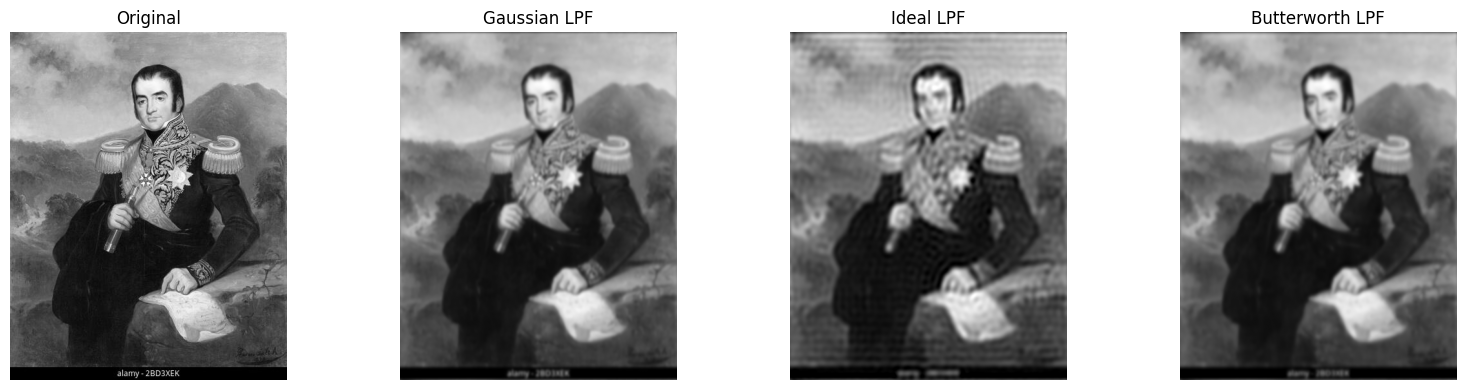

In [24]:
D0 = 40
ORDER = 2

gaussian_lp = apply_frequency_filter(gray, gaussian_lpf(gray.shape, D0))
ideal_lp = apply_frequency_filter(gray, ideal_lpf(gray.shape, D0))
butterworth_lp = apply_frequency_filter(gray, butterworth_lpf(gray.shape, D0, ORDER))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
items = [
    (gray, "Original"),
    (gaussian_lp, "Gaussian LPF"),
    (ideal_lp, "Ideal LPF"),
    (butterworth_lp, "Butterworth LPF")
]
for ax, (result, title) in zip(axes, items):
    ax.imshow(result, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Ringing and Blurring

Ideal LPF mempunyai batas frekuensi yang sangat tajam. Cut-off yang lebih kecil menghilangkan lebih banyak komponen frekuensi tinggi sehingga blur semakin kuat. Karena transisi filter Ideal sangat abrupt, efek ringing dapat muncul di sekitar tepi yang tajam.

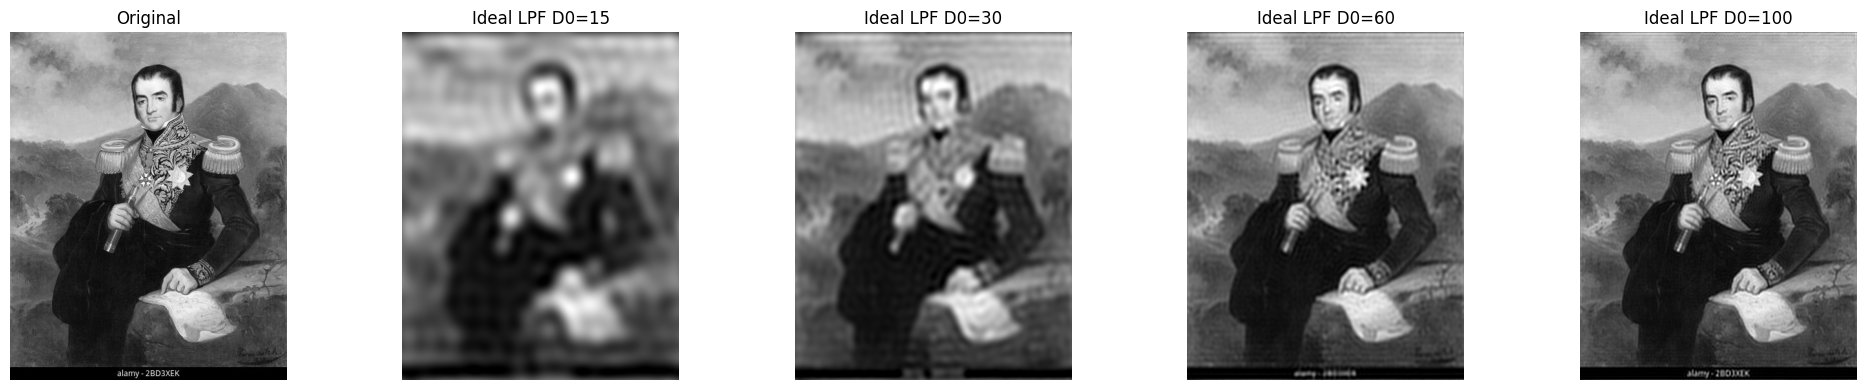

In [25]:
cutoff_values = [15, 30, 60, 100]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

for ax, d0 in zip(axes[1:], cutoff_values):
    result = apply_frequency_filter(gray, ideal_lpf(gray.shape, d0))
    ax.imshow(result, cmap="gray")
    ax.set_title(f"Ideal LPF D0={d0}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 5. High-Pass Filtering

High-pass filter menekan frekuensi rendah dan mempertahankan frekuensi tinggi. Karena informasi tepi dan detail banyak berada pada komponen frekuensi tinggi, hasil HPF dapat digunakan untuk menonjolkan edge dan detail.

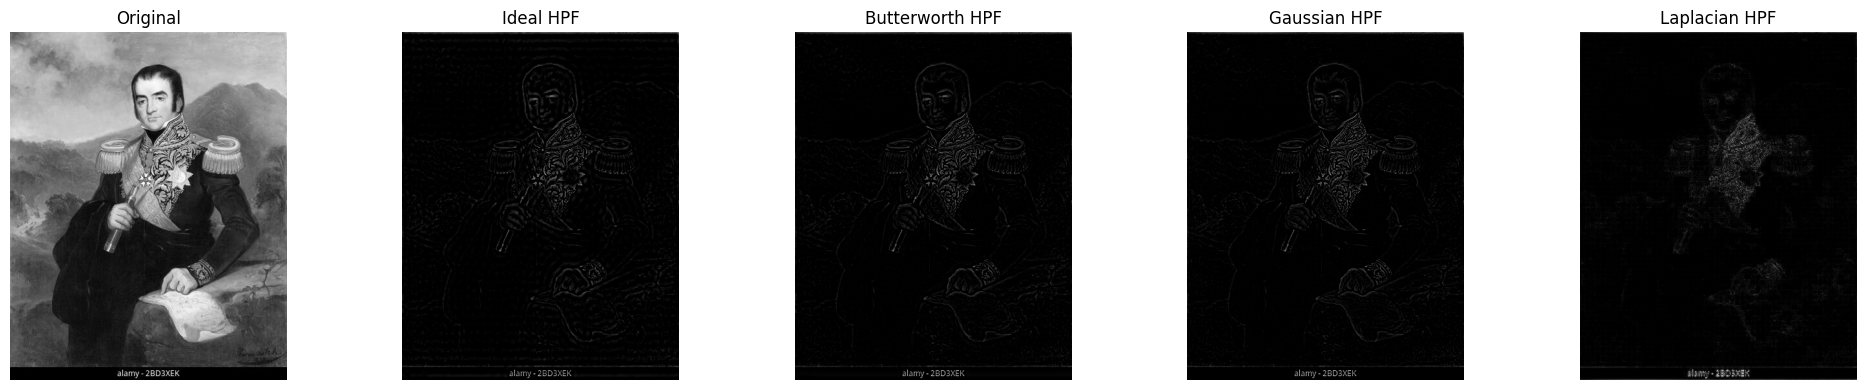

In [26]:
ideal_hp = apply_frequency_filter(gray, ideal_hpf(gray.shape, D0))
butterworth_hp = apply_frequency_filter(gray, butterworth_hpf(gray.shape, D0, ORDER))
gaussian_hp = apply_frequency_filter(gray, gaussian_hpf(gray.shape, D0))

# Laplacian HPF di frequency domain
rows, cols = gray.shape
u = np.arange(rows) - rows // 2
v = np.arange(cols) - cols // 2
V, U = np.meshgrid(v, u)
laplacian_H = -4 * (np.pi**2) * (U**2 + V**2)

F = np.fft.fftshift(np.fft.fft2(gray.astype(np.float32)))
G = F * laplacian_H
laplacian_hp = np.real(np.fft.ifft2(np.fft.ifftshift(G)))
laplacian_hp = cv2.normalize(np.abs(laplacian_hp), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
items = [
    (gray, "Original"),
    (ideal_hp, "Ideal HPF"),
    (butterworth_hp, "Butterworth HPF"),
    (gaussian_hp, "Gaussian HPF"),
    (laplacian_hp, "Laplacian HPF")
]
for ax, (result, title) in zip(axes, items):
    ax.imshow(result, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 6. Applications of HPFs

High-pass filtering dapat digunakan untuk menonjolkan batas objek, tekstur, dan detail halus. Dalam image enhancement, informasi tersebut dapat digunakan untuk memperjelas citra, terutama ketika detail tepi kurang terlihat.

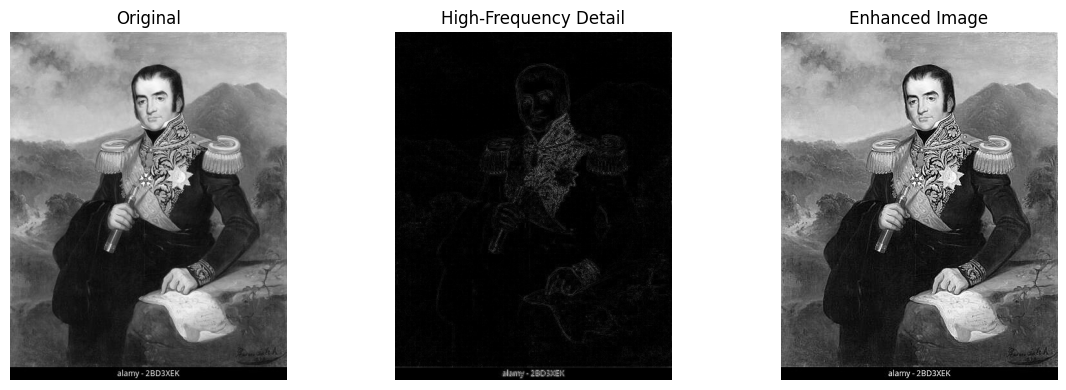

In [27]:
# Contoh aplikasi: unsharp-style enhancement menggunakan Gaussian blur + detail HPF
blur = cv2.GaussianBlur(gray, (5, 5), 1.0)
detail = gray.astype(np.float32) - blur.astype(np.float32)
enhanced = gray.astype(np.float32) + 1.0 * detail
enhanced = np.clip(enhanced, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(np.abs(detail), cmap="gray")
axes[1].set_title("High-Frequency Detail")
axes[2].imshow(enhanced, cmap="gray")
axes[2].set_title("Enhanced Image")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 7. Save Results

Semua hasil utama disimpan ke folder `results` agar dapat langsung digunakan sebagai dokumentasi tugas di GitHub.

In [28]:
# Simpan hasil utama
def save_result(filename, img):
    path = os.path.join(OUTPUT_FOLDER, filename)
    Image.fromarray(np.clip(img, 0, 255).astype(np.uint8)).save(path)
    return path

save_result("original_gray.png", gray)
save_result("smoothing_linear.png", linear_result)
save_result("gaussian_filter.png", gaussian_result)
save_result("median_filter.png", median_result)
save_result("laplacian_sharpening.png", laplacian_result)
save_result("gaussian_lpf.png", gaussian_lp)
save_result("ideal_lpf.png", ideal_lp)
save_result("butterworth_lpf.png", butterworth_lp)
save_result("ideal_hpf.png", ideal_hp)
save_result("butterworth_hpf.png", butterworth_hp)
save_result("gaussian_hpf.png", gaussian_hp)
save_result("laplacian_hpf.png", laplacian_hp)
save_result("enhanced_application.png", enhanced)

print("All results saved to:", OUTPUT_FOLDER)

All results saved to: /content/drive/MyDrive/PCD_Assignment02/results


## 8. Comparison of Filtering Methods for Different Image Conditions

Pada bagian ini dilakukan perbandingan visual terhadap lima kondisi citra yang dibuat dari foto 1. Tidak digunakan PSNR, SSIM, atau metrik lain karena fokus praktikum adalah karakteristik filtering pada materi.

Perbandingan dilakukan dengan melihat hasil beberapa filter yang sudah dibuat pada notebook terhadap masing-masing kondisi.

| Kondisi Citra | Metode yang Perlu Dibandingkan | Fokus Pengamatan |
|---|---|---|
| **Blurred Image** | Laplacian Sharpening, Ideal HPF, Butterworth HPF, Gaussian HPF | Apakah detail dan edge yang melemah karena blur menjadi lebih terlihat |
| **Dark Image** | Gaussian Filter, Low-Pass, High-Pass, Laplacian | Filtering terutama memengaruhi smoothing/detail; materi ini tidak memberikan filter khusus untuk menaikkan brightness |
| **Bright Image** | Gaussian Filter, Low-Pass, High-Pass, Laplacian | Filtering terutama memengaruhi smoothing/detail; materi ini tidak memberikan filter khusus untuk menurunkan brightness |
| **Low-Contrast Image** | High-Pass dan Laplacian dibandingkan dengan Low-Pass | Apakah edge/perubahan intensitas menjadi lebih terlihat |
| **Salt & Pepper Noise** | Smoothing Linear, Gaussian, dan terutama Median Filter | Seberapa baik noise impulsif berkurang tanpa terlalu menghaluskan citra |




In [29]:


comparison_conditions = {
    "Blurred Image": blurred_image,
    "Dark Image": dark_image,
    "Bright Image": bright_image,
    "Low-Contrast Image": low_contrast_image,
    "Salt & Pepper Noise": salt_pepper_image
}

def to_gray(img):
    return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

def hpf_enhancement(gray_img, H, alpha=1.0):
    F = np.fft.fftshift(
        np.fft.fft2(gray_img.astype(np.float32))
    )

    high_frequency = np.real(
        np.fft.ifft2(
            np.fft.ifftshift(F * H)
        )
    )

    enhanced = (
        gray_img.astype(np.float32)
        + alpha * high_frequency
    )

    return np.clip(
        enhanced, 0, 255
    ).astype(np.uint8)

comparison_results = {}

for condition_name, img in comparison_conditions.items():

    condition_gray = to_gray(img)

    linear = smoothing_linear_filter(condition_gray, 5)
    gaussian = gaussian_filter(condition_gray, 5, 1.0)
    median = median_filter(condition_gray, 5)
    laplacian, _ = laplacian_sharpen(condition_gray)

    gaussian_lp = apply_frequency_filter(
        condition_gray,
        gaussian_lpf(condition_gray.shape, D0)
    )

    ideal_lp = apply_frequency_filter(
        condition_gray,
        ideal_lpf(condition_gray.shape, D0)
    )

    butterworth_lp = apply_frequency_filter(
        condition_gray,
        butterworth_lpf(condition_gray.shape, D0, ORDER)
    )

    ideal_hp = hpf_enhancement(
        condition_gray,
        ideal_hpf(condition_gray.shape, D0)
    )

    butterworth_hp = hpf_enhancement(
        condition_gray,
        butterworth_hpf(condition_gray.shape, D0, ORDER)
    )

    gaussian_hp = hpf_enhancement(
        condition_gray,
        gaussian_hpf(condition_gray.shape, D0)
    )

    comparison_results[condition_name] = {
        "Input": condition_gray,
        "Smoothing Linear": linear,
        "Gaussian Filter": gaussian,
        "Median Filter": median,
        "Laplacian Sharpening": laplacian,
        "Gaussian LPF": gaussian_lp,
        "Ideal LPF": ideal_lp,
        "Butterworth LPF": butterworth_lp,
        "Ideal HPF Enhancement": ideal_hp,
        "Butterworth HPF Enhancement": butterworth_hp,
        "Gaussian HPF Enhancement": gaussian_hp
    }

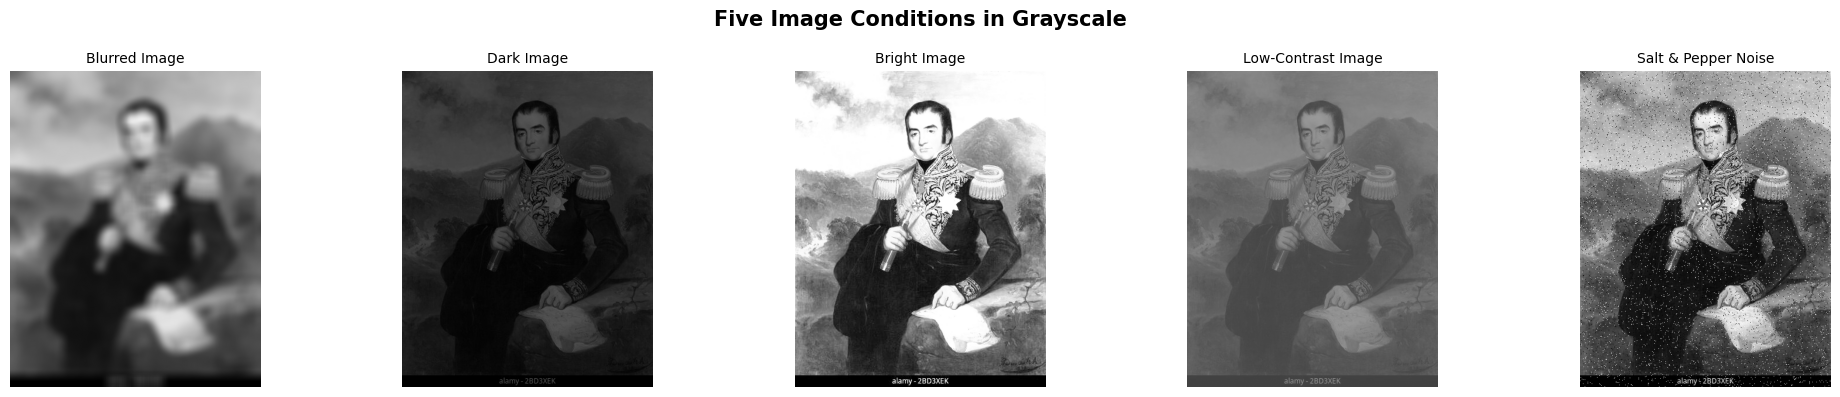

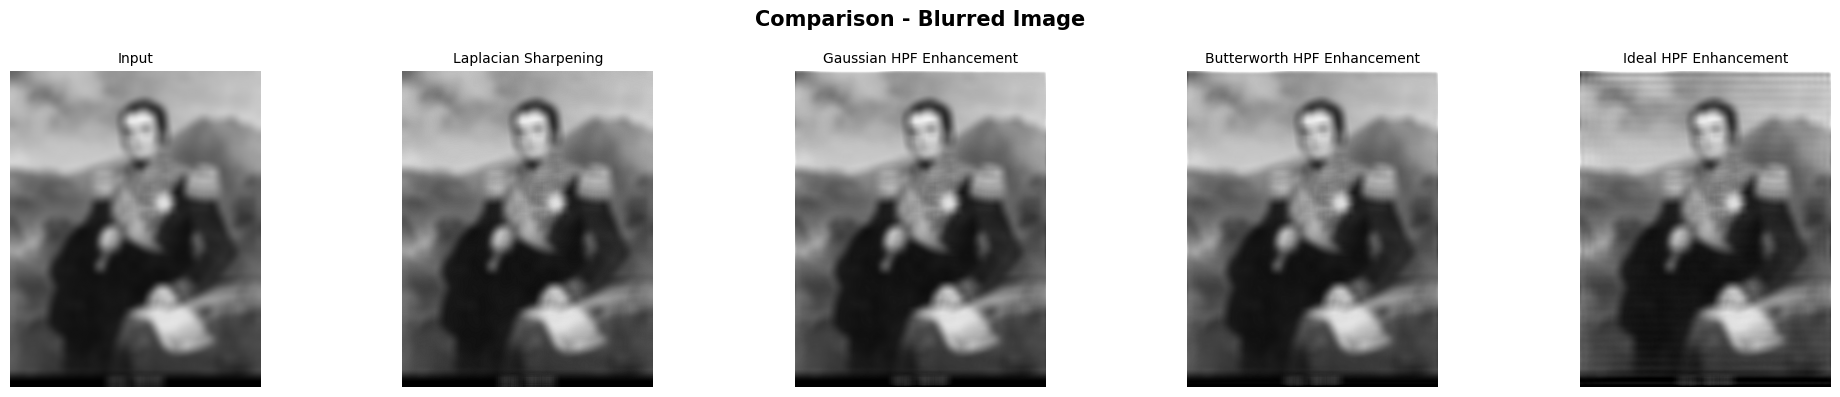

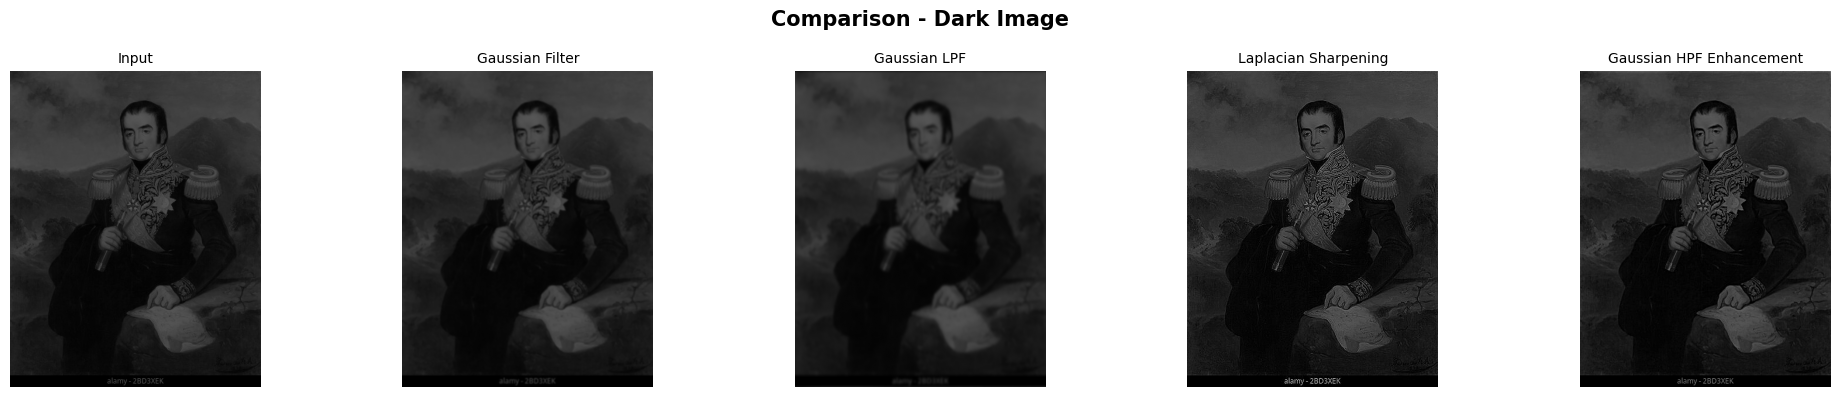

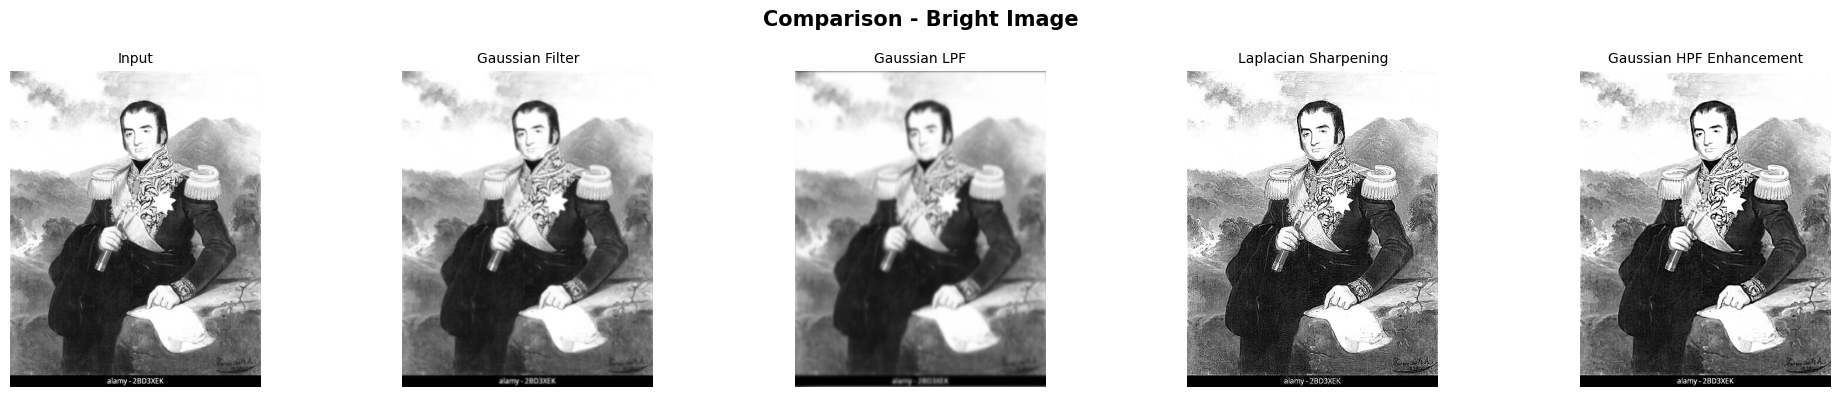

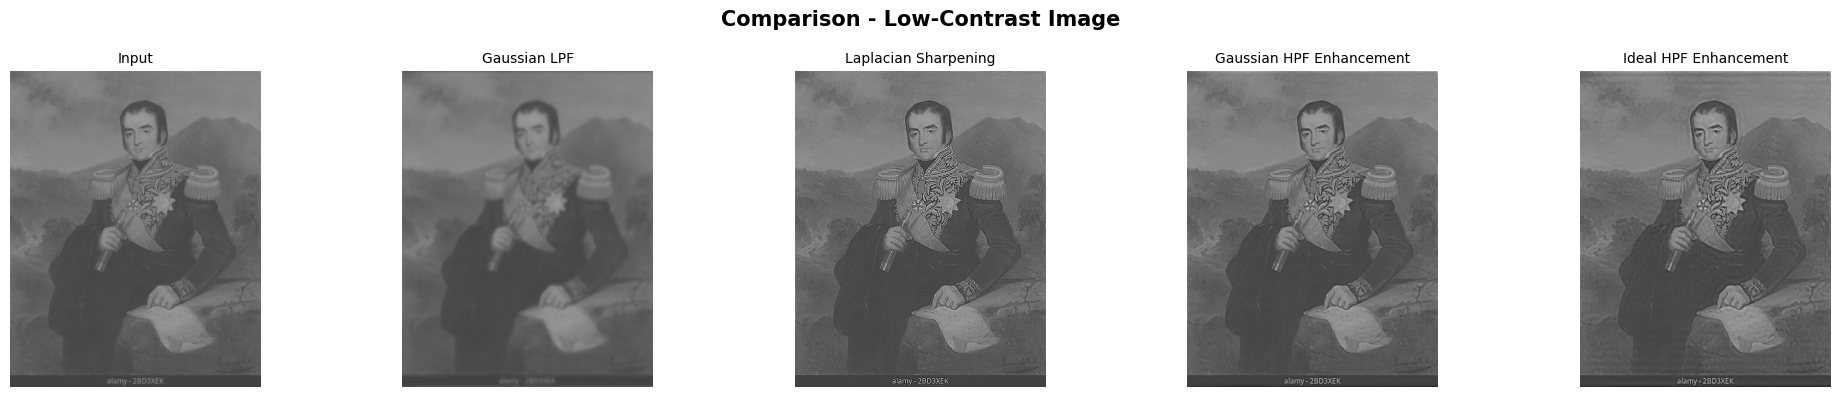

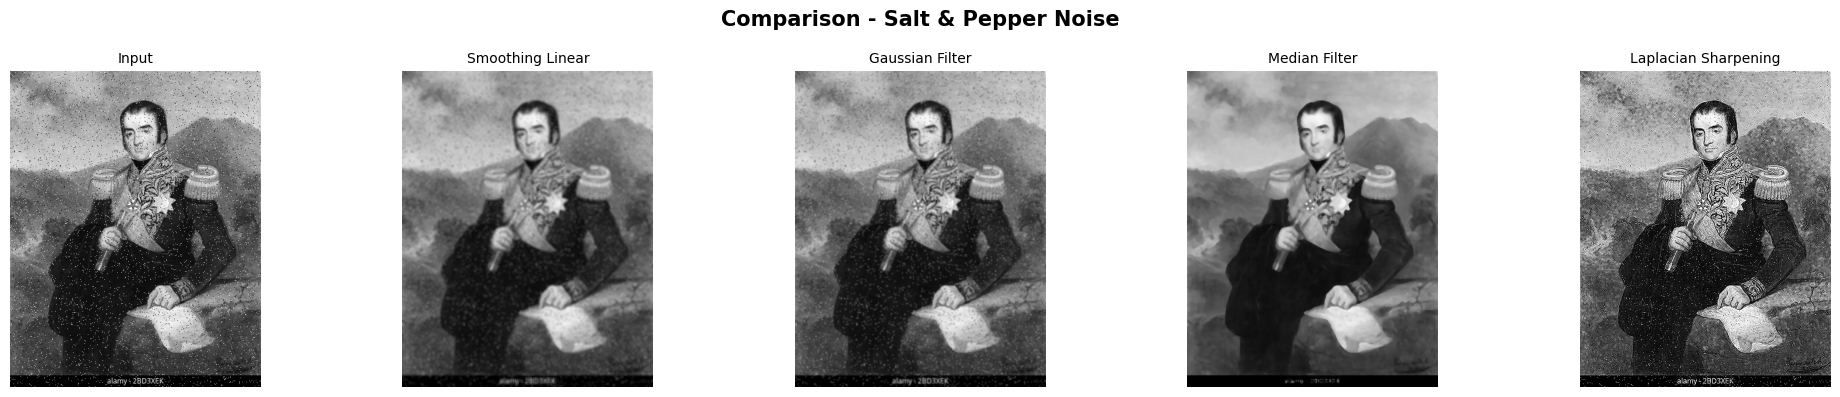

In [30]:

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, (condition_name, img) in zip(
    axes, comparison_conditions.items()
):
    condition_gray = to_gray(img)

    ax.imshow(
        condition_gray,
        cmap="gray",
        vmin=0,
        vmax=255
    )
    ax.set_title(condition_name, fontsize=10)
    ax.axis("off")

plt.suptitle(
    "Five Image Conditions in Grayscale",
    fontsize=15,
    fontweight="bold"
)
plt.tight_layout()
plt.show()

methods_to_compare = {
    "Blurred Image": [
        "Input",
        "Laplacian Sharpening",
        "Gaussian HPF Enhancement",
        "Butterworth HPF Enhancement",
        "Ideal HPF Enhancement"
    ],
    "Dark Image": [
        "Input",
        "Gaussian Filter",
        "Gaussian LPF",
        "Laplacian Sharpening",
        "Gaussian HPF Enhancement"
    ],
    "Bright Image": [
        "Input",
        "Gaussian Filter",
        "Gaussian LPF",
        "Laplacian Sharpening",
        "Gaussian HPF Enhancement"
    ],
    "Low-Contrast Image": [
        "Input",
        "Gaussian LPF",
        "Laplacian Sharpening",
        "Gaussian HPF Enhancement",
        "Ideal HPF Enhancement"
    ],
    "Salt & Pepper Noise": [
        "Input",
        "Smoothing Linear",
        "Gaussian Filter",
        "Median Filter",
        "Laplacian Sharpening"
    ]
}

for condition_name, method_names in methods_to_compare.items():
    results = comparison_results[condition_name]

    fig, axes = plt.subplots(
        1,
        len(method_names),
        figsize=(20, 4)
    )

    for ax, method_name in zip(axes, method_names):
        ax.imshow(
            results[method_name],
            cmap="gray",
            vmin=0,
            vmax=255
        )
        ax.set_title(method_name, fontsize=10)
        ax.axis("off")

    plt.suptitle(
        f"Comparison - {condition_name}",
        fontsize=15,
        fontweight="bold"
    )
    plt.tight_layout()
    plt.show()


## 9. Final Comparison / Conclusion

Pada bagian comparison, setiap kondisi Blurred, Dark, Bright, Low-Contrast, dan Salt & Pepper** terlebih dahulu dikonversi ke grayscale dari citra kondisinya masing-masing. Untuk menjaga karakteristik brightness dan contrast, visualisasi menggunakan rentang tetap 0-255. Dengan demikian Dark Image tetap terlihat gelap, Bright Image tetap terlihat terang, dan Low-Contrast Image tetap terlihat memiliki kontras rendah.

Untuk memilih metode yang sesuai, hasil diamati secara visual dengan mempertimbangkan tujuan masing-masing filter pada materi.

| Kondisi Citra | Metode yang lebih sesuai untuk diamati |
|---|---|
| **Blurred Image** | Laplacian Sharpening / High-Pass Filtering |
| **Dark Image** | Laplacian Sharpening / High-Pass Filtering untuk menonjolkan detail |
| **Bright Image** | Gaussian / Low-Pass Filtering untuk smoothing |
| **Low-Contrast Image** | Laplacian Sharpening / High-Pass Filtering untuk menonjolkan detail |
| **Salt & Pepper Noise** | **Median Filter** |

Tidak ada satu filter yang paling baik untuk semua kondisi. Pemilihan metode bergantung pada karakteristik citra dan tujuan enhancement. Untuk Salt & Pepper Noise, median filter merupakan metode yang paling sesuai secara konsep karena materi menjelaskan penggunaannya untuk impulsive atau salt-and-pepper noise.
